# =====================================================================
#  Do Macroeconomic Variables Improve Rupiah Forecasts under Conditional Heteroskedasticity?
Leakage-free rolling-window evaluation of ARIMAX(2)-GARCH(1,1) for IDR/USD (JISDOR)
# ---------------------------------------------------------------------

Key anti-leakage design:
* The model orders (AR(2), GARCH(1,1)) are FROZEN in advance; only the coefficients are re-estimated on each window.
* Each window uses ONLY observations up to the forecast origin `o`.
* At every horizon, including h = 1, the exogenous variables are held at their last observed level at the origin, so their future first differences are ZERO. No future macro value (FFR/BI/CPI) is ever read.
# =====================================================================

In [97]:
import warnings; warnings.filterwarnings("ignore")
!pip install -q arch==8.0.0
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import statsmodels.api as sm
from arch.univariate import ARX, GARCH
from arch.unitroot import ADF, PhillipsPerron
from scipy import stats
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch
from statsmodels.tsa.vector_ar.vecm import coint_johansen
from statsmodels.tsa.api import VAR

np.random.seed(42)
rng = np.random.default_rng(42)   # for the interval simulations

# ---------------------------------------------------------------------
# 1. Load data
# ---------------------------------------------------------------------

In [98]:
DATA_FILE = "merged_data_clean.csv"          # columns: date, fx, ffr, bi, cpi
df = pd.read_csv(DATA_FILE, parse_dates=["date"])
df = df.set_index("date").sort_index()

# ---------------------------------------------------------------------
# 2. Preprocessing: stationary transforms
fx  -> log-return (in %), I(0)
exogenous (I(1)) -> first difference
# ---------------------------------------------------------------------

In [99]:
df["logret"] = np.log(df["fx"]).diff() * 100.0
for c in ["ffr", "bi", "cpi"]:
    df["d_" + c] = df[c].diff()

data = df.dropna().copy()
y    = data["logret"].to_numpy()
Xz   = data[["d_ffr", "d_bi", "d_cpi"]].to_numpy()
lvl  = data["fx"].to_numpy()
logp = np.log(lvl)                                   # for the ECM model
Wlvl = data[["ffr", "cpi", "bi"]].to_numpy(float)    # macro levels for cointegration
n    = len(data)

print("=" * 70); print("DATA SUMMARY"); print("=" * 70)
print(f"Aligned observations : {n}")
print(f"Sample period        : {data.index[0].date()}  to  {data.index[-1].date()}")
print(f"Max fx               : {lvl.max():.0f}  on {data.index[int(np.argmax(lvl))].date()}")
print(f"Min fx               : {lvl.min():.0f}  on {data.index[int(np.argmin(lvl))].date()}")

DATA SUMMARY
Aligned observations : 2003
Sample period        : 2018-04-03  to  2026-07-27
Max fx               : 18171  on 2026-06-08
Min fx               : 13612  on 2020-01-27


# ---------------------------------------------------------------------
# 3. Stationarity tests (Table 1): ADF & PP on level and first difference
# ---------------------------------------------------------------------

In [100]:
print("=" * 70); print("TABLE I  Unit-root tests (p-values)"); print("=" * 70)
print(f"{'Series':<18}{'ADF lvl':>9}{'PP lvl':>9}{'ADF d':>9}{'PP d':>9}{'  Order':>8}")

def unit_root_row(level_series, name):
    lv = level_series.dropna().to_numpy(); dv = np.diff(lv)
    adf_l = ADF(lv).pvalue; pp_l = PhillipsPerron(lv).pvalue
    adf_d = ADF(dv).pvalue; pp_d = PhillipsPerron(dv).pvalue
    order = "I(1)" if (adf_l > 0.05 and adf_d < 0.05) else "check"
    print(f"{name:<18}{adf_l:>9.4f}{pp_l:>9.4f}{adf_d:>9.4f}{pp_d:>9.4f}{order:>8}")

unit_root_row(np.log(df["fx"]), "log(fx)")
for c, nm in [("ffr", "Federal Funds"), ("bi", "BI Rate"), ("cpi", "CPI")]:
    unit_root_row(df[c], nm)

TABLE I  Unit-root tests (p-values)
Series              ADF lvl   PP lvl    ADF d     PP d   Order
log(fx)              0.6641   0.6885   0.0000   0.0000    I(1)
Federal Funds        0.8531   0.8571   0.0000   0.0000    I(1)
BI Rate              0.4281   0.7380   0.0000   0.0000    I(1)
CPI                  0.9669   0.9749   0.0000   0.0000    I(1)


# 4. Johansen cointegration test\nLog exchange rate + three exogenous variables in levels.

In [101]:
joh = pd.DataFrame({"logX": np.log(df["fx"]), "ffr": df["ffr"],
                    "bi": df["bi"], "cpi": df["cpi"]}).dropna()
p = max(int(VAR(joh.to_numpy()).select_order(maxlags=10).aic), 1)
res = coint_johansen(joh, det_order=0, k_ar_diff=p - 1)   # det_order=0: constant term

print("=" * 70); print("JOHANSEN COINTEGRATION TEST"); print("=" * 70)
print(f"Observations : {len(joh)}    VAR lag (AIC, max 10) : {p}  (k_ar_diff = {p-1})")
print(f"\n{'H0: r <=':<9}{'trace':>9}{'cv95':>9}{'max-eig':>10}{'cv95':>9}")
for i in range(len(res.lr1)):
    print(f"{i:<9}{res.lr1[i]:>9.2f}{res.cvt[i, 1]:>9.2f}{res.lr2[i]:>10.2f}{res.cvm[i, 1]:>9.2f}")
r_trace = next((i for i in range(len(res.lr1)) if res.lr1[i] <= res.cvt[i, 1]), len(res.lr1))
r_maxeig = next((i for i in range(len(res.lr2)) if res.lr2[i] <= res.cvm[i, 1]), len(res.lr2))
print(f"\nCointegration rank at 5%: trace r = {r_trace}, max-eigenvalue r = {r_maxeig}")

JOHANSEN COINTEGRATION TEST
Observations : 2004    VAR lag (AIC, max 10) : 2  (k_ar_diff = 1)

H0: r <=     trace     cv95   max-eig     cv95
0            70.14    47.85     57.03    27.59
1            13.11    29.80     11.77    21.13
2             1.34    15.49      1.32    14.26
3             0.02     3.84      0.02     3.84

Cointegration rank at 5%: trace r = 1, max-eigenvalue r = 1


# 4a. ACF and PACF of the log returns (order identification)

In [102]:
from statsmodels.tsa.stattools import acf, pacf
WINDOW = 1000
for seg_name, sl in {"First window (development)": slice(0, WINDOW),
                     "Last window (representative)": slice(n - WINDOW, n)}.items():
    x = y[sl]; band = 1.96 / np.sqrt(len(x))
    a = acf(x, nlags=10)[1:]; pa = pacf(x, nlags=10)[1:]
    print(f"\n{seg_name}: {data.index[sl][0].date()} to {data.index[sl][-1].date()}   (95% band = ±{band:.3f})")
    print(f"{'lag':>4}{'ACF':>9}{'PACF':>9}")
    for k in range(10):
        print(f"{k+1:>4}{a[k]:>+9.3f}{'*' if abs(a[k]) > band else ' '}{pa[k]:>+8.3f}{'*' if abs(pa[k]) > band else ' '}")


First window (development): 2018-04-03 to 2022-05-19   (95% band = ±0.062)
 lag      ACF     PACF
   1   +0.196*  +0.196*
   2   +0.111*  +0.076*
   3   +0.045   +0.011 
   4   +0.053   +0.036 
   5   +0.080*  +0.063*
   6   -0.011   -0.047 
   7   +0.051   +0.050 
   8   -0.056   -0.078*
   9   +0.122*  +0.144*
  10   +0.036   -0.007 

Last window (representative): 2022-05-25 to 2026-07-27   (95% band = ±0.062)
 lag      ACF     PACF
   1   +0.101*  +0.101*
   2   -0.109*  -0.121*
   3   +0.021   +0.047 
   4   +0.035   +0.014 
   5   -0.010   -0.009 
   6   -0.034   -0.028 
   7   +0.096*  +0.102*
   8   +0.065*  +0.036 
   9   -0.011   +0.002 
  10   -0.065*  -0.059 


# 4b. Model order selection (AR order and GARCH order)
Compared on the first window (development segment, before any forecast origin)
and on the representative (last) window.

In [103]:
from statsmodels.stats.diagnostic import acorr_ljungbox
WINDOW = 1000
segments = {"First window (development)": slice(0, WINDOW),
            "Last window (representative)": slice(n - WINDOW, n)}
rows_ord = []
for seg_name, sl in segments.items():
    for p_ar in [1, 2, 3]:
        for (gp, gq) in [(1, 1), (1, 2), (2, 1)]:
            m = ARX(y[sl], lags=list(range(1, p_ar + 1)), x=Xz[sl], rescale=False)
            m.volatility = GARCH(p=gp, o=0, q=gq)
            r = m.fit(disp="off")
            z = np.asarray(r.std_resid); z = z[~np.isnan(z)]
            lbp = acorr_ljungbox(z, lags=[20], return_df=True)["lb_pvalue"].iloc[0]
            rows_ord.append({"Segment": seg_name,
                             "Period": f"{data.index[sl][0].date()} to {data.index[sl][-1].date()}",
                             "Model": f"AR({p_ar})-GARCH({gp},{gq})",
                             "AIC": round(r.aic, 2), "BIC": round(r.bic, 2),
                             "Ljung-Box(20) p": round(lbp, 3)})
order_table = pd.DataFrame(rows_ord)
print(order_table.to_string(index=False))
order_table.to_csv("table_order_selection.csv", index=False)

                     Segment                   Period            Model    AIC    BIC  Ljung-Box(20) p
  First window (development) 2018-04-03 to 2022-05-19 AR(1)-GARCH(1,1) 777.50 816.76            0.010
  First window (development) 2018-04-03 to 2022-05-19 AR(1)-GARCH(1,2) 776.93 821.09            0.008
  First window (development) 2018-04-03 to 2022-05-19 AR(1)-GARCH(2,1) 779.50 823.66            0.010
  First window (development) 2018-04-03 to 2022-05-19 AR(2)-GARCH(1,1) 780.41 824.56            0.017
  First window (development) 2018-04-03 to 2022-05-19 AR(2)-GARCH(1,2) 779.72 828.77            0.014
  First window (development) 2018-04-03 to 2022-05-19 AR(2)-GARCH(2,1) 782.41 831.47            0.017
  First window (development) 2018-04-03 to 2022-05-19 AR(3)-GARCH(1,1) 782.50 831.55            0.015
  First window (development) 2018-04-03 to 2022-05-19 AR(3)-GARCH(1,2) 781.33 835.28            0.011
  First window (development) 2018-04-03 to 2022-05-19 AR(3)-GARCH(2,1) 784.50 838.

#----------------------------------------------------------------------
# 5. ARIMAX(2)-GARCH(1,1) estimates (Table II)
## 5.1 Representative window + residual diagnostics
Uses the final full window as the representative window
#----------------------------------------------------------------------

In [104]:
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch
from statsmodels.stats.stattools import jarque_bera

WINDOW = 1000
rep = slice(n - WINDOW, n)
mrep = ARX(y[rep], lags=[1, 2], x=Xz[rep], rescale=False)
mrep.volatility = GARCH(p=1, o=0, q=1)
rres = mrep.fit(disp="off")

print("=" * 70); print("Representative window (last 1000 obs) - full estimates"); print("=" * 70)
print(f"Window period: {data.index[n - WINDOW].date()} to {data.index[n - 1].date()}")
print(rres.summary())

# Residual diagnostics on the standardized residuals
zr = np.asarray(rres.std_resid); zr = zr[~np.isnan(zr)]
lb     = acorr_ljungbox(zr, lags=[20], return_df=True)
archlm = het_arch(zr, nlags=10)          # (LM stat, LM p-value, F stat, F p-value)
jb     = jarque_bera(zr)                 # (JB stat, p-value, skewness, kurtosis)

print("\nResidual diagnostics (standardized residuals, representative window):")
print(f"  Ljung-Box(20) = {lb['lb_stat'].iloc[0]:.2f}, p = {lb['lb_pvalue'].iloc[0]:.3f}")
print(f"  ARCH-LM(10)   = {archlm[0]:.2f}, p = {archlm[1]:.3f}")
print(f"  Jarque-Bera   = {jb[0]:.2f}, p = {jb[1]:.3g}")

Representative window (last 1000 obs) - full estimates
Window period: 2022-05-25 to 2026-07-27
                          AR-X - GARCH Model Results                          
Dep. Variable:                      y   R-squared:                       0.025
Mean Model:                      AR-X   Adj. R-squared:                  0.020
Vol Model:                      GARCH   Log-Likelihood:               -326.507
Distribution:                  Normal   AIC:                           671.015
Method:            Maximum Likelihood   BIC:                           715.167
                                        No. Observations:                  998
Date:                Mon, Oct 05 2026   Df Residuals:                      992
Time:                        19:20:27   Df Model:                            6
                                 Mean Model                                 
                 coef    std err          t      P>|t|      95.0% Conf. Int.
----------------------------------------

In [105]:
print("\nLag sensitivity (p-values):")
for L in [5, 10, 15, 20]:
    lb_p = acorr_ljungbox(zr, lags=[L], return_df=True)["lb_pvalue"].iloc[0]
    ar_p = het_arch(zr, nlags=L)[1]
    print(f"  lag {L:>2}:  Ljung-Box p = {lb_p:.3f}   ARCH-LM p = {ar_p:.3f}")


Lag sensitivity (p-values):
  lag  5:  Ljung-Box p = 0.838   ARCH-LM p = 0.663
  lag 10:  Ljung-Box p = 0.159   ARCH-LM p = 0.380
  lag 15:  Ljung-Box p = 0.153   ARCH-LM p = 0.614
  lag 20:  Ljung-Box p = 0.238   ARCH-LM p = 0.810


In [106]:
print(f"\nStandardized residuals: mean = {zr.mean():.3f}, sd = {zr.std():.3f}, "
      f"skewness = {jb[2]:.2f}, kurtosis = {jb[3]:.2f}")
lb_sq = acorr_ljungbox(zr**2, lags=[20], return_df=True)
print(f"Ljung-Box(20) on squared standardized residuals: p = {lb_sq['lb_pvalue'].iloc[0]:.3f}")


Standardized residuals: mean = -0.010, sd = 1.001, skewness = -0.03, kurtosis = 6.21
Ljung-Box(20) on squared standardized residuals: p = 0.767


In [107]:
# Same diagnostics for the nested ARIMA-GARCH control (representative window)
m0rep = ARX(y[rep], lags=[1, 2], rescale=False)
m0rep.volatility = GARCH(p=1, o=0, q=1)
r0rep = m0rep.fit(disp="off")
z0 = np.asarray(r0rep.std_resid); z0 = z0[~np.isnan(z0)]
lb0 = acorr_ljungbox(z0, lags=[20], return_df=True)
ar0 = het_arch(z0, nlags=10); jb0 = jarque_bera(z0)
print("\nNested ARIMA-GARCH control (representative window):")
print(f"  Ljung-Box(20) = {lb0['lb_stat'].iloc[0]:.2f}, p = {lb0['lb_pvalue'].iloc[0]:.3f}")
print(f"  ARCH-LM(10)   = {ar0[0]:.2f}, p = {ar0[1]:.3f}")
print(f"  Jarque-Bera   = {jb0[0]:.2f}, p = {jb0[1]:.3g}")
print(f"  alpha1 + beta1 = {r0rep.params['alpha[1]'] + r0rep.params['beta[1]']:.3f}")


Nested ARIMA-GARCH control (representative window):
  Ljung-Box(20) = 24.02, p = 0.242
  ARCH-LM(10)   = 10.17, p = 0.426
  Jarque-Bera   = 491.42, p = 1.95e-107
  alpha1 + beta1 = 0.955


## 5.2 Cross-window coefficient distribution (right block of Table II) + Figure 6
Re-estimates the frozen ARIMAX(2)-GARCH(1,1) on every rolling window.

In [108]:
ALPHA = 0.05
n_windows = n - WINDOW + 1
print(f"{n} obs -> {n_windows} rolling windows")

rows, failed = [], 0
for i in range(n_windows):
    sl = slice(i, i + WINDOW)
    m = ARX(y[sl], lags=[1, 2], x=Xz[sl], rescale=False)   # same setting as all other fits
    m.volatility = GARCH(p=1, o=0, q=1)
    try:
        r = m.fit(disp="off", cov_type="robust")
    except Exception:
        failed += 1; continue
    for name in r.params.index:
        rows.append({"param": name, "coef": float(r.params[name]), "pval": float(r.pvalues[name])})
    if (i + 1) % 100 == 0: print(f"  {i + 1}/{n_windows}")
print(f"Windows estimated: {n_windows - failed}   skipped (no convergence): {failed}")

long_df = pd.DataFrame(rows)
summary = (long_df.groupby("param")
           .agg(mean_coef=("coef", "mean"), sd_coef=("coef", "std"),
                pct_positive=("coef", lambda s: 100 * (s > 0).mean()),
                pct_sig=("pval", lambda s: 100 * (s < ALPHA).mean())))

2003 obs -> 1004 rolling windows
  100/1004
  200/1004
  300/1004
  400/1004
  500/1004
  600/1004
  700/1004
  800/1004
  900/1004
  1000/1004
Windows estimated: 1004   skipped (no convergence): 0


## 5.3 Combined Table II (representative window + cross-window)

In [109]:
LABELS = {"Const": "Constant", "y[1]": "logret(t-1)", "y[2]": "logret(t-2)",
          "x0": "ΔFFR", "x1": "ΔBI", "x2": "ΔCPI",
          "omega": "ω", "alpha[1]": "α1", "beta[1]": "β1"}
MEAN_EQ = ["Const", "y[1]", "y[2]", "x0", "x1", "x2"]; VAR_EQ = ["omega", "alpha[1]", "beta[1]"]
def fmt_p(p): return "<0.001" if p < 0.001 else f"{p:.3f}"
def make_row(name):
    return {"Parameter": LABELS[name],
            "Coef.": round(float(rres.params[name]), 4), "Std. err.": round(float(rres.std_err[name]), 4),
            "p-value": fmt_p(float(rres.pvalues[name])),
            "Mean": round(float(summary.loc[name, "mean_coef"]), 4), "SD": round(float(summary.loc[name, "sd_coef"]), 4),
            "% coef>0": round(float(summary.loc[name, "pct_positive"]), 1),
            "% windows p<0.05": round(float(summary.loc[name, "pct_sig"]), 1)}
table2 = pd.DataFrame([make_row(k) for k in MEAN_EQ + VAR_EQ]).set_index("Parameter")
print("=" * 90); print("TABLE II  ARIMAX(2)-GARCH(1,1) ESTIMATES, REPRESENTATIVE WINDOW AND CROSS-WINDOW"); print("=" * 90)
print("Mean Equation"); print(table2.loc[[LABELS[k] for k in MEAN_EQ]].to_string())
print("\nVariance Equation"); print(table2.loc[[LABELS[k] for k in VAR_EQ]].to_string())
print(f"\nNote: Returns in percent; N = {int(rres.nobs)}; log-likelihood = {rres.loglikelihood:.2f}; "
      f"AIC = {rres.aic:.2f}; BIC = {rres.bic:.2f}.")
table2.to_csv("table2.csv")

TABLE II  ARIMAX(2)-GARCH(1,1) ESTIMATES, REPRESENTATIVE WINDOW AND CROSS-WINDOW
Mean Equation
              Coef.  Std. err. p-value    Mean      SD  % coef>0  % windows p<0.05
Parameter                                                                         
Constant     0.0278     0.0102   0.006  0.0103  0.0096      74.3              22.0
logret(t-1)  0.1134     0.0345   0.001  0.1248  0.0152     100.0             100.0
logret(t-2) -0.1137     0.0356   0.001 -0.0657  0.0514      15.0              53.8
ΔFFR        -0.3617     0.2551   0.156 -0.2676  0.1461       4.8               0.0
ΔBI          0.3503     0.2830   0.216  0.5179  0.2068      96.2              42.2
ΔCPI         0.0892     0.1651   0.589  0.0544  0.0377      92.0               0.0

Variance Equation
            Coef.  Std. err. p-value    Mean      SD  % coef>0  % windows p<0.05
Parameter                                                                       
ω          0.0060     0.0037   0.104  0.0045  0.0016     100

# ---------------------------------------------------------------------
# 6. Rolling-window, leakage-free point forecasts
Builds the level-error dictionary `err` for all five models. Horizons h = 1, 5, 10, 20, 60.
## 6.1 Base loop: RW, ARIMA-GARCH, ARIMAX-GARCH
# ---------------------------------------------------------------------

In [110]:
H = [1, 5, 10, 20, 60]
err = {m: {h: [] for h in H} for m in ["arimax", "arima", "rw"]}
act = {h: [] for h in H}
exog_future = np.zeros(3)               # future macro diffs are unknown at the origin -> 0

for o in range(WINDOW - 1, n - 1):      # o = index of last in-sample observation
    tr = slice(o - WINDOW + 1, o + 1)
    ytr, Xtr = y[tr], Xz[tr]
    mx = ARX(ytr, lags=[1, 2], x=Xtr, rescale=False); mx.volatility = GARCH(p=1, o=0, q=1)
    px = mx.fit(disp="off").params.to_numpy(); cX, a1X, a2X, bX = px[0], px[1], px[2], px[3:6]
    m0 = ARX(ytr, lags=[1, 2], rescale=False); m0.volatility = GARCH(p=1, o=0, q=1)
    p0 = m0.fit(disp="off").params.to_numpy(); c0, a10, a20 = p0[0], p0[1], p0[2]
    for h in H:
        if o + h > n - 1: continue
        l1, l2, s = y[o], y[o - 1], 0.0
        for _ in range(h):
            rh = cX + a1X*l1 + a2X*l2 + bX @ exog_future; s += rh; l2, l1 = l1, rh
        lx = lvl[o] * np.exp(s / 100.0)
        l1, l2, s = y[o], y[o - 1], 0.0
        for _ in range(h):
            rh = c0 + a10*l1 + a20*l2; s += rh; l2, l1 = l1, rh
        l0 = lvl[o] * np.exp(s / 100.0)
        a = lvl[o + h]; act[h].append(a)
        err["arimax"][h].append(a - lx); err["arima"][h].append(a - l0); err["rw"][h].append(a - lvl[o])
    if (o - WINDOW + 2) % 200 == 0: print(f"  {o - WINDOW + 2}/{n - WINDOW}")
print("base loop done")

  200/1003
  400/1003
  600/1003
  800/1003
  1000/1003
base loop done


## 6.2 Random walk with drift

In [111]:
err["rw_drift"] = {h: [] for h in H}
for o in range(WINDOW - 1, n - 1):
    tr = slice(o - WINDOW + 1, o + 1)
    drift = np.mean(y[tr]) / 100.0                 # mean log-return in the window
    for h in H:
        if o + h > n - 1: continue
        err["rw_drift"][h].append(lvl[o] * np.exp(h * drift) - lvl[o + h])
print("rw_drift done")

rw_drift done


## 6.3 ARIMAX-ECM-GARCH
Engle-Granger long-run regression on each window's in-sample levels forms the equilibrium
error `z_{t-1}`; the mean equation adds it as a regressor with coefficient lambda.

In [112]:
def fit_ec_term(logp_win, Wlvl_win):
    D = np.column_stack([np.ones(len(logp_win)), Wlvl_win])
    coef, *_ = np.linalg.lstsq(D, logp_win, rcond=None)
    return coef[0], coef[1:], logp_win - D @ coef

err["arimax_ecm"] = {h: [] for h in H}
for o in range(WINDOW - 1, n - 1):
    tr = slice(o - WINDOW + 1, o + 1); ytr = y[tr]
    a_ec, b_ec, zw = fit_ec_term(logp[tr], Wlvl[tr])
    zlag = np.empty_like(zw); zlag[0] = 0.0; zlag[1:] = zw[:-1]
    ok = True
    try:
        me = ARX(ytr, lags=[1, 2], x=np.column_stack([Xz[tr], zlag]), rescale=False)
        me.volatility = GARCH(p=1, o=0, q=1)
        pe = me.fit(disp="off").params.to_numpy()
        cE, a1E, a2E, lamE = pe[0], pe[1], pe[2], pe[6]
    except Exception:
        ok = False
    for h in H:
        if o + h > n - 1: continue
        if not ok:
            err["arimax_ecm"][h].append(lvl[o] - lvl[o + h]); continue
        r1, r2 = y[o], y[o - 1]; logp_k = logp[o]; Weq = a_ec + b_ec @ Wlvl[o]
        for k in range(1, h + 1):
            yhat = cE + a1E*r1 + a2E*r2 + lamE*(logp_k - Weq)
            logp_k += yhat / 100.0; r2, r1 = r1, yhat
        err["arimax_ecm"][h].append(np.exp(logp_k) - lvl[o + h])
    if (o - WINDOW + 2) % 200 == 0: print(f"  {o - WINDOW + 2}/{n - WINDOW}")
print("ecm done")

  200/1003
  400/1003
  600/1003
  800/1003
  1000/1003
ecm done


# ------------------------------------------
# 7. Point-forecast accuracy (Table III)
# ------------------------------------------

In [113]:
def metrics(e, a):
    e = np.asarray(e, float); a = np.asarray(a, float)
    return np.mean(np.abs(e)), np.sqrt(np.mean(e**2)), 100 * np.mean(np.abs(e / a))

NAMES = [("rw","RW"),("rw_drift","RW-drift"),("arima","ARIMA-GARCH"),
         ("arimax","ARIMAX-GARCH"),("arimax_ecm","ARIMAX-ECM-GARCH")]
print("=" * 70); print("TABLE III  Point-forecast accuracy (MAE & RMSE in IDR, MAPE in %)"); print("=" * 70)
for h in H:
    a = np.asarray(act[h], float); print(f"\nHorizon h = {h}")
    print(f"  {'model':<18}{'MAE':>9}{'RMSE':>9}{'MAPE%':>9}")
    for key, lab in NAMES:
        mae, rmse, mape = metrics(err[key][h], a)
        print(f"  {lab:<18}{mae:>9.2f}{rmse:>9.2f}{mape:>9.4f}")

TABLE III  Point-forecast accuracy (MAE & RMSE in IDR, MAPE in %)

Horizon h = 1
  model                   MAE     RMSE    MAPE%
  RW                    41.14    55.98   0.2586
  RW-drift              40.98    55.92   0.2577
  ARIMA-GARCH           40.89    55.44   0.2571
  ARIMAX-GARCH          40.89    55.43   0.2571
  ARIMAX-ECM-GARCH      41.12    55.65   0.2586

Horizon h = 5
  model                   MAE     RMSE    MAPE%
  RW                    99.13   129.93   0.6234
  RW-drift              97.53   129.39   0.6140
  ARIMA-GARCH           97.46   129.05   0.6138
  ARIMAX-GARCH          97.45   129.03   0.6137
  ARIMAX-ECM-GARCH     100.69   131.50   0.6337

Horizon h = 10
  model                   MAE     RMSE    MAPE%
  RW                   148.63   189.97   0.9354
  RW-drift             145.60   188.46   0.9176
  ARIMA-GARCH          144.81   187.28   0.9132
  ARIMAX-GARCH         144.83   187.26   0.9133
  ARIMAX-ECM-GARCH     149.78   193.16   0.9443

Horizon h = 20
  model 

#----------------------------------------------------------
# 8. Clark-West significance tests (Tables IV & V)
Tested in log-return space (one-sided, HAC Newey-West standard error, lag h-1).
#----------------------------------------------------------

In [114]:
# 8. Clark-West tests (Tables IV and V), log-return space, one-sided, HAC lag h-1
import numpy as np, statsmodels.api as sm
from scipy.stats import norm

# sign of stored level error: +1 if err = actual - forecast, -1 if err = forecast - actual
SIGN = {"arimax": 1, "arima": 1, "rw": 1, "rw_drift": -1, "arimax_ecm": -1}

def _pred_level(model, h):
    e = np.asarray(err[model][h], float); a = np.asarray(act[h], float)
    return a - SIGN[model]*e                          # recover the forecast level

def cw_p(small, large, h):                            # small = nested, large = nesting model
    a  = np.asarray(act[h], float)
    ps, pl = _pred_level(small, h), _pred_level(large, h)
    e_s = 100*np.log(a/ps); e_l = 100*np.log(a/pl)    # log-return-space errors (%)
    ft  = e_s**2 - (e_l**2 - (100*np.log(ps/pl))**2)  # Clark-West adjusted loss differential
    res = sm.OLS(ft, np.ones(len(ft))).fit(cov_type='HAC', cov_kwds={'maxlags': max(0, h-1)})
    return float(norm.sf(float(res.tvalues[0])))      # one-sided p-value

def rmse_gain(small, large, h):                       # % RMSE reduction of large vs small, log-return space
    a  = np.asarray(act[h], float)
    e_s = 100*np.log(a/_pred_level(small, h)); e_l = 100*np.log(a/_pred_level(large, h))
    return 100*(1 - np.sqrt(np.mean(e_l**2))/np.sqrt(np.mean(e_s**2)))

def cell(small, large, h):
    return f"{cw_p(small, large, h):.3f} ({rmse_gain(small, large, h):+.2f})"

print("="*78); print("TABLE IV  Clark-West p-value (RMSE gain %), ARIMAX-GARCH vs benchmarks"); print("="*78)
print(f"  {'h':>3}{'vs RW':>17}{'vs RW-drift':>17}{'vs ARIMA':>17}")
for h in H:
    print(f"  {h:>3}{cell('rw','arimax',h):>17}{cell('rw_drift','arimax',h):>17}{cell('arima','arimax',h):>17}")

print("\n"+"="*78); print("TABLE V  Clark-West p-value (RMSE gain %), ARIMAX-ECM-GARCH vs benchmarks"); print("="*78)
print(f"  {'h':>3}{'vs RW':>17}{'vs RW-drift':>17}{'vs ARIMA':>17}{'vs ARIMAX':>17}")
for h in H:
    print(f"  {h:>3}{cell('rw','arimax_ecm',h):>17}{cell('rw_drift','arimax_ecm',h):>17}"
          f"{cell('arima','arimax_ecm',h):>17}{cell('arimax','arimax_ecm',h):>17}")

TABLE IV  Clark-West p-value (RMSE gain %), ARIMAX-GARCH vs benchmarks
    h            vs RW      vs RW-drift         vs ARIMA
    1    0.000 (+0.97)    0.000 (+0.89)    0.066 (+0.02)
    5    0.013 (+0.61)    0.059 (+0.24)    0.238 (+0.02)
   10    0.014 (+1.26)    0.060 (+0.57)    0.410 (+0.01)
   20    0.029 (+2.04)    0.143 (+0.64)    0.622 (-0.03)
   60    0.053 (+5.11)    0.449 (-0.42)    0.899 (-0.27)

TABLE V  Clark-West p-value (RMSE gain %), ARIMAX-ECM-GARCH vs benchmarks
    h            vs RW      vs RW-drift         vs ARIMA        vs ARIMAX
    1    0.000 (+0.56)    0.001 (+0.48)    0.414 (-0.39)    0.434 (-0.41)
    5    0.299 (-1.40)    0.312 (-1.77)    0.380 (-2.00)    0.384 (-2.02)
   10    0.246 (-2.01)    0.269 (-2.72)    0.336 (-3.30)    0.337 (-3.31)
   20    0.171 (-2.34)    0.218 (-3.80)    0.252 (-4.50)    0.249 (-4.47)
   60    0.068 (+2.50)    0.142 (-3.19)    0.154 (-3.03)    0.150 (-2.75)


#----------------------------------------------------------
# Giacomini-White significance tests
Giacomini-White UNCONDITIONAL (HAC) predictive ability (ARIMAX vs nested ARIMA)

Squared-error loss in log-return space, the same space as the Clark-West test.
#----------------------------------------------------------

In [115]:
import numpy as np, statsmodels.api as sm

def logerr(model, h):
    a = np.asarray(act[h], float)
    return 100*np.log(a / _pred_level(model, h))       # log-return-space error (%)

def gw_uncond(e_small, e_large):
    d = np.asarray(e_small)**2 - np.asarray(e_large)**2  # d > 0 favors the large (ARIMAX) model
    n_ = len(d); L = max(1, int(round(n_**(1/3))))       # HAC lag n^(1/3)
    ols = sm.OLS(d, np.ones(n_)).fit(cov_type="HAC", cov_kwds={"maxlags": L})
    return float(ols.tvalues[0]), float(ols.pvalues[0]), L

print("=" * 70); print("Giacomini-White (unconditional, HAC), log-return space"); print("=" * 70)
for h in H:
    t, p, L = gw_uncond(logerr("arima", h), logerr("arimax", h))
    print(f"  h={h:2d}  t={t:6.2f}  p={p:.3f}  HAC lag={L}  favors {'ARIMAX' if t > 0 else 'ARIMA'}")

Giacomini-White (unconditional, HAC), log-return space
  h= 1  t=  1.57  p=0.116  HAC lag=10  favors ARIMAX
  h= 5  t=  0.57  p=0.567  HAC lag=10  favors ARIMAX
  h=10  t=  0.19  p=0.847  HAC lag=10  favors ARIMAX
  h=20  t= -0.42  p=0.676  HAC lag=10  favors ARIMA
  h=60  t= -2.09  p=0.037  HAC lag=10  favors ARIMA


In [116]:
print("Giacomini-White UNCONDITIONAL (HAC) predictive ability (ARIMAX vs nested ARIMA)")
for h in H:
    d = np.array(err["arima"][h])**2 - np.array(err["arimax"][h])**2
    t, p, L = giacomini_white(err["arima"][h], err["arimax"][h], conditional=False)
    favors = "ARIMAX" if t > 0 else "ARIMA"
    print(f"  h={h:2d}  t={t:6.2f}  p={p:.3f}  mean(d)={d.mean():+.4f}  favors {favors}")

Giacomini-White UNCONDITIONAL (HAC) predictive ability (ARIMAX vs nested ARIMA)
  h= 1  t=  1.53  p=0.127  mean(d)=+0.9997  favors ARIMAX
  h= 5  t=  0.56  p=0.578  mean(d)=+5.6114  favors ARIMAX
  h=10  t=  0.24  p=0.814  mean(d)=+8.1254  favors ARIMAX
  h=20  t= -0.37  p=0.708  mean(d)=-39.6136  favors ARIMA
  h=60  t= -2.17  p=0.030  mean(d)=-1267.8537  favors ARIMA


In [117]:
from statsmodels.stats.multitest import multipletests
def holm(pvals): return np.round(multipletests(pvals, method="holm")[1], 3)
print("\nHolm-adjusted p-values across horizons")
print("  CW vs RW      :", holm([cw_p("rw", "arimax", h) for h in H]))
print("  CW vs RW-drift:", holm([cw_p("rw_drift", "arimax", h) for h in H]))
print("  CW vs ARIMA   :", holm([cw_p("arima", "arimax", h) for h in H]))
print("  GW vs ARIMA   :", holm([gw_uncond(logerr("arima", h), logerr("arimax", h))[1] for h in H]))


Holm-adjusted p-values across horizons
  CW vs RW      : [0.    0.052 0.052 0.058 0.058]
  CW vs RW-drift: [0.001 0.235 0.235 0.285 0.449]
  CW vs ARIMA   : [0.331 0.952 1.    1.    1.   ]
  GW vs ARIMA   : [0.464 1.    1.    1.    0.184]


#-----------------------------------------------------------------
# 9. 95% interval-forecast evaluation (Figure 5)
Monte Carlo simulation of 2,000 paths per origin. Six models, including a frozen-variance
ARIMAX ablation. Coverage, relative width, interval score, Kupiec and Christoffersen tests.
#-----------------------------------------------------------------

In [118]:
rng = np.random.default_rng(42)   # reset seed so interval results do not depend on cell run order
S = 2000; Z = stats.norm.ppf(1 - ALPHA / 2); QLO, QHI = 100 * ALPHA / 2, 100 * (1 - ALPHA / 2)
MODELS = ["rw", "rw_drift", "arima_garch", "arimax_garch", "arimax_frozen", "arimax_ecm_garch"]
band = {m: {h: {"lo": [], "hi": [], "act": []} for h in H} for m in MODELS}
def store(m, h, lo, hi, a): band[m][h]["lo"].append(lo); band[m][h]["hi"].append(hi); band[m][h]["act"].append(a)
def gstate(res, ne):
    p = res.params.to_numpy(); sig = np.asarray(res.conditional_volatility, float); sig = sig[~np.isnan(sig)]
    eps = np.asarray(res.resid, float); eps = eps[~np.isnan(eps)]
    return p[0], p[1], p[2], p[3+ne], p[4+ne], p[5+ne], eps[-1], sig[-1]**2
def sim(o, c, a1, a2, w, al, be, epsT, hT, h, garch=True, fvar=None):
    r1 = np.full(S, y[o]); r2 = np.full(S, y[o-1]); ep = np.full(S, epsT); hv = np.full(S, hT); s = np.zeros(S)
    for _ in range(h):
        hv = w + al*ep**2 + be*hv if garch else np.full(S, fvar)
        ep = np.sqrt(hv) * rng.standard_normal(S); rk = c + a1*r1 + a2*r2 + ep; s += rk; r2, r1 = r1, rk
    return lvl[o] * np.exp(s / 100.0)
def sim_ecm(o, c, a1, a2, lam, w, al, be, epsT, hT, a_ec, b_ec, h):
    r1 = np.full(S, y[o]); r2 = np.full(S, y[o-1]); ep = np.full(S, epsT); hv = np.full(S, hT)
    lp = np.full(S, logp[o]); Weq = a_ec + b_ec @ Wlvl[o]
    for _ in range(h):
        hv = w + al*ep**2 + be*hv; ep = np.sqrt(hv) * rng.standard_normal(S)
        yk = c + a1*r1 + a2*r2 + lam*(lp - Weq) + ep; lp = lp + yk/100.0; r2, r1 = r1, yk
    return np.exp(lp)

for o in range(WINDOW - 1, n - 1):
    tr = slice(o - WINDOW + 1, o + 1); sd = y[tr].std(ddof=1); mu = y[tr].mean()
    for h in H:
        if o + h > n - 1: continue
        store("rw", h, lvl[o]*np.exp(-Z*np.sqrt(h)*sd/100.0), lvl[o]*np.exp(Z*np.sqrt(h)*sd/100.0), lvl[o+h])
        store("rw_drift", h, lvl[o]*np.exp((h*mu-Z*np.sqrt(h)*sd)/100.0), lvl[o]*np.exp((h*mu+Z*np.sqrt(h)*sd)/100.0), lvl[o+h])
    m0 = ARX(y[tr], lags=[1,2], rescale=False); m0.volatility = GARCH(1,0,1); s0 = gstate(m0.fit(disp="off"), 0)
    mx = ARX(y[tr], lags=[1,2], x=Xz[tr], rescale=False); mx.volatility = GARCH(1,0,1); sx = gstate(mx.fit(disp="off"), 3)
    denom = 1 - sx[4] - sx[5]; vun = sx[3]/denom if denom > 1e-6 else np.var(y[tr])
    a_ec, b_ec, zw = fit_ec_term(logp[tr], Wlvl[tr]); zlag = np.empty_like(zw); zlag[0]=0.0; zlag[1:]=zw[:-1]
    ok = True
    try:
        me = ARX(y[tr], lags=[1,2], x=np.column_stack([Xz[tr], zlag]), rescale=False); me.volatility = GARCH(1,0,1)
        pe = me.fit(disp="off"); pp = pe.params.to_numpy(); cE,a1E,a2E,lamE = pp[0],pp[1],pp[2],pp[6]; wE,alE,beE = pp[7],pp[8],pp[9]
        sig = np.asarray(pe.conditional_volatility, float); sig = sig[~np.isnan(sig)]
        rs = np.asarray(pe.resid, float); rs = rs[~np.isnan(rs)]; epE, hTE = rs[-1], sig[-1]**2
    except Exception:
        ok = False
    for h in H:
        if o + h > n - 1: continue
        lo, hi = np.percentile(sim(o, *s0, h, garch=True), [QLO, QHI]); store("arima_garch", h, lo, hi, lvl[o+h])
        lo, hi = np.percentile(sim(o, *sx, h, garch=True), [QLO, QHI]); store("arimax_garch", h, lo, hi, lvl[o+h])
        lo, hi = np.percentile(sim(o, sx[0],sx[1],sx[2],sx[3],sx[4],sx[5],sx[6],sx[7], h, garch=False, fvar=vun), [QLO, QHI])
        store("arimax_frozen", h, lo, hi, lvl[o+h])
        if ok:
            lo, hi = np.percentile(sim_ecm(o, cE,a1E,a2E,lamE,wE,alE,beE,epE,hTE, a_ec, b_ec, h), [QLO, QHI])
        else:
            lo = lvl[o]*np.exp((h*mu-Z*np.sqrt(h)*sd)/100.0); hi = lvl[o]*np.exp((h*mu+Z*np.sqrt(h)*sd)/100.0)
        store("arimax_ecm_garch", h, lo, hi, lvl[o+h])
    if (o - WINDOW + 2) % 200 == 0: print(f"  {o - WINDOW + 2}/{n - WINDOW}")
print("interval simulation done")

  200/1003
  400/1003
  600/1003
  800/1003
  1000/1003
interval simulation done


In [119]:
def interval_score(lo, hi, a, alpha=ALPHA):
    lo, hi, a = map(lambda v: np.asarray(v, float), (lo, hi, a))
    return ((hi - lo) + (2/alpha)*(lo - a)*(a < lo) + (2/alpha)*(a - hi)*(a > hi)).mean()
def kupiec(viol, p=ALPHA):
    viol = np.asarray(viol, int); N = len(viol); x = viol.sum(); pi = x/N
    if x == 0 or x == N: return np.nan
    lr = -2*((N-x)*np.log(1-p)+x*np.log(p)) + 2*((N-x)*np.log(1-pi)+x*np.log(pi))
    return float(1 - stats.chi2.cdf(lr, 1))
def christoffersen(viol, p=ALPHA):
    v = np.asarray(viol, int); n00=n01=n10=n11=0
    for i in range(1, len(v)):
        a, b = v[i-1], v[i]
        n00 += (a==0 and b==0); n01 += (a==0 and b==1); n10 += (a==1 and b==0); n11 += (a==1 and b==1)
    x = v.sum(); N = len(v); pi = x/N
    if x == 0 or x == N: return np.nan
    lr_uc = -2*((N-x)*np.log(1-p)+x*np.log(p)) + 2*((N-x)*np.log(1-pi)+x*np.log(pi))
    pi01 = n01/(n00+n01) if (n00+n01)>0 else 0; pi11 = n11/(n10+n11) if (n10+n11)>0 else 0
    pio = (n01+n11)/(n00+n01+n10+n11)
    def L(pr,k1,k0): return 0.0 if pr<=0 or pr>=1 else k1*np.log(pr)+k0*np.log(1-pr)
    lr_ind = -2*(L(pio,n01+n11,n00+n10) - (L(pi01,n01,n00)+L(pi11,n11,n10)))
    return float(1 - stats.chi2.cdf(lr_uc + lr_ind, 2))

LAB = {"rw":"RW","rw_drift":"RW-drift","arima_garch":"ARIMA-GARCH","arimax_garch":"ARIMAX-GARCH",
       "arimax_frozen":"ARIMAX-frozen","arimax_ecm_garch":"ARIMAX-ECM-GARCH"}
print("=" * 78); print("95% INTERVAL-FORECAST EVALUATION (nominal coverage = 95%)"); print("=" * 78)
for h in H:
    print(f"\nHorizon h = {h}")
    print(f"  {'model':<18}{'cov%':>7}{'width':>9}{'rel%':>8}{'IS':>9}{'Kupiec':>9}{'Christ':>9}")
    for m in MODELS:
        lo = np.array(band[m][h]["lo"]); hi = np.array(band[m][h]["hi"]); a = np.array(band[m][h]["act"])
        viol = ((a < lo) | (a > hi)).astype(int)
        cov = 100*(1 - viol.mean()); width = (hi - lo).mean(); rel = 100*((hi - lo)/a).mean()
        ks = kupiec(viol); cs = christoffersen(viol)
        print(f"  {LAB[m]:<18}{cov:>7.1f}{width:>9.1f}{rel:>8.2f}{interval_score(lo,hi,a):>9.1f}"
              f"{ks:>9.3f}{cs:>9.3f}")

95% INTERVAL-FORECAST EVALUATION (nominal coverage = 95%)

Horizon h = 1
  model                cov%    width    rel%       IS   Kupiec   Christ
  RW                   95.5    241.9    1.52    317.5    0.448    0.128
  RW-drift             95.5    241.9    1.52    318.1    0.448    0.128
  ARIMA-GARCH          94.5    212.5    1.34    292.1    0.489    0.423
  ARIMAX-GARCH         94.3    211.5    1.33    293.6    0.331    0.377
  ARIMAX-frozen        95.5    238.9    1.50    313.1    0.448    0.010
  ARIMAX-ECM-GARCH     94.4    211.6    1.33    294.5    0.405    0.546

Horizon h = 5
  model                cov%    width    rel%       IS   Kupiec   Christ
  RW                   95.3    540.9    3.41    697.4    0.665    0.000
  RW-drift             95.4    541.2    3.41    701.7    0.561    0.000
  ARIMA-GARCH          93.8    516.2    3.25    701.2    0.091    0.000
  ARIMAX-GARCH         93.7    515.4    3.24    701.7    0.068    0.000
  ARIMAX-frozen        96.2    569.8    3.59    

# =========================================================
# 11. Robustness checks
# =========================================================

In [120]:
import numpy as np, pandas as pd, statsmodels.api as sm
from arch.univariate import ARX, GARCH, EGARCH, Normal, StudentsT
from scipy.stats import norm

def _cw_p(e_small, e_large, f_small, f_large, h):
    # one-sided Clark-West, HAC lag h-1 (same as Tables IV and V)
    ft = e_small**2 - (e_large**2 - (f_small - f_large)**2)
    ols = sm.OLS(ft, np.ones(len(ft))).fit(cov_type='HAC', cov_kwds={'maxlags': max(0, h-1)})
    return float(norm.sf(float(ols.tvalues[0])))

def _gw_p(e_small, e_large):
    # unconditional Giacomini-White, squared-error loss, HAC lag n^(1/3)
    d = np.asarray(e_small)**2 - np.asarray(e_large)**2
    n_ = len(d); L = max(1, int(round(n_**(1/3))))
    ols = sm.OLS(d, np.ones(n_)).fit(cov_type='HAC', cov_kwds={'maxlags': L})
    return float(ols.pvalues[0]), float(ols.tvalues[0])

def run_rolling(y, Xz, lvl, window=1000, dist='normal', vol='Garch', o=0,
                horizons=(1, 5, 10, 20, 60), o_start=None, o_end=None):
    n = len(y); k = Xz.shape[1]; exog_future = np.zeros(k)
    distrib = StudentsT() if dist == 't' else Normal()
    mk_vol = (lambda: EGARCH(p=1, o=1, q=1)) if vol == 'EGARCH' else (lambda: GARCH(p=1, o=o, q=1))
    es = {m: {h: [] for h in horizons} for m in ['arima', 'arimax']}   # log-return errors (%)
    fs = {m: {h: [] for h in horizons} for m in ['arima', 'arimax']}   # cumulative-return forecasts (%)
    le = {m: {h: [] for h in horizons} for m in ['arima', 'arimax']}   # level errors (IDR)
    lo = (window - 1) if o_start is None else max(window - 1, o_start)
    hi = (n - 1) if o_end is None else min(n - 1, o_end)
    skipped, used = 0, 0
    for ori in range(lo, hi):
        tr = slice(ori - window + 1, ori + 1); ytr, Xtr = y[tr], Xz[tr]
        try:
            mx = ARX(ytr, lags=[1, 2], x=Xtr, rescale=False)
            mx.volatility, mx.distribution = mk_vol(), distrib
            px = mx.fit(disp='off').params.to_numpy()
            cX, a1X, a2X, bX = px[0], px[1], px[2], px[3:3+k]
            m0 = ARX(ytr, lags=[1, 2], rescale=False)
            m0.volatility, m0.distribution = mk_vol(), distrib
            p0 = m0.fit(disp='off').params.to_numpy()
            c0, a10, a20 = p0[0], p0[1], p0[2]
        except Exception:
            skipped += 1; continue
        used += 1
        for h in horizons:
            if ori + h > n - 1: continue
            l1, l2, sX = y[ori], y[ori-1], 0.0
            for _ in range(h):
                rh = cX + a1X*l1 + a2X*l2 + bX @ exog_future; sX += rh; l2, l1 = l1, rh
            l1, l2, s0 = y[ori], y[ori-1], 0.0
            for _ in range(h):
                rh = c0 + a10*l1 + a20*l2; s0 += rh; l2, l1 = l1, rh
            lx, l0, a = lvl[ori]*np.exp(sX/100.0), lvl[ori]*np.exp(s0/100.0), lvl[ori+h]
            r = 100.0*np.log(lvl[ori+h]/lvl[ori])
            fs['arimax'][h].append(sX); fs['arima'][h].append(s0)
            es['arimax'][h].append(r - sX); es['arima'][h].append(r - s0)
            le['arimax'][h].append(a - lx); le['arima'][h].append(a - l0)
    out = {'origins': used, 'skipped': skipped, 'first_origin': lo}
    for h in horizons:
        eS, eL = np.array(es['arima'][h]), np.array(es['arimax'][h])
        fS, fL = np.array(fs['arima'][h]), np.array(fs['arimax'][h])
        rS = np.sqrt(np.mean(np.array(le['arima'][h])**2))
        rL = np.sqrt(np.mean(np.array(le['arimax'][h])**2))
        gwp, gwt = _gw_p(eS, eL)
        out[h] = {'rmse_small': rS, 'rmse_large': rL, 'pct_gain': 100*(rS - rL)/rS,
                  'cw_p': _cw_p(eS, eL, fS, fL, h), 'gw_p': gwp, 'gw_t': gwt}
    return out

configs = [
    ('Baseline (Normal, w=1000, GARCH)', dict(dist='normal', window=1000, vol='Garch')),
    ('Student-t errors',                 dict(dist='t',      window=1000, vol='Garch')),
    ('Window 750',                       dict(dist='normal', window=750,  vol='Garch')),
    ('Window 1250',                      dict(dist='normal', window=1250, vol='Garch')),
    ('EGARCH',                           dict(dist='normal', window=1000, vol='EGARCH')),
    ('GJR-GARCH',                        dict(dist='normal', window=1000, vol='Garch', o=1)),
]

rows = []
for name, kw in configs:
    res = run_rolling(y, Xz, lvl, **kw)
    rows.append({'Config': name,
                 'Eval. starts': str(data.index[res['first_origin']].date()),
                 'Origins': res['origins'],
                 'Skipped': res['skipped'],
                 'Macro gain h=1 (%)': round(res[1]['pct_gain'], 2),
                 'CW p (h=1)': round(res[1]['cw_p'], 3),
                 'GW p (h=1)': round(res[1]['gw_p'], 3),
                 'GW favors': 'ARIMAX' if res[1]['gw_t'] > 0 else 'ARIMA',
                 'Beats nested?': 'No' if res[1]['cw_p'] > 0.05 else 'Yes'})
    print('done:', name)

robust_table = pd.DataFrame(rows)
print(robust_table.to_string(index=False))
robust_table.to_csv("table_robustness.csv", index=False)

done: Baseline (Normal, w=1000, GARCH)
done: Student-t errors
done: Window 750
done: Window 1250
done: EGARCH
done: GJR-GARCH
                          Config Eval. starts  Origins  Skipped  Macro gain h=1 (%)  CW p (h=1)  GW p (h=1) GW favors Beats nested?
Baseline (Normal, w=1000, GARCH)   2022-05-19     1003        0                0.02       0.066       0.116    ARIMAX            No
                Student-t errors   2022-05-19     1003        0                0.01       0.194       0.433    ARIMAX            No
                      Window 750   2021-05-06     1253        0                0.02       0.082       0.184    ARIMAX            No
                     Window 1250   2023-05-24      753        0                0.02       0.037       0.058    ARIMAX           Yes
                          EGARCH   2022-05-19     1003        0                0.02       0.146       0.257    ARIMAX            No
                       GJR-GARCH   2022-05-19     1003        0                0.0

# =========================================================
# Subperiod robustness: monetary tightening vs post-tightening
 (uses err, act, band from Sections 6-9; no re-estimation needed)
# =========================================================

In [121]:
import numpy as np, pandas as pd, statsmodels.api as sm
from scipy.stats import norm

SPLIT = pd.Timestamp("2024-07-01")                    # tightening cycle: May 2022-Jun 2024; post-tightening: Jul 2024-Jul 2026
origins = data.index[WINDOW - 1 : n - 1]             # forecast-origin dates (same order as err/act lists)
SIGN = {"arimax": 1, "arima": 1, "rw": 1, "rw_drift": -1, "arimax_ecm": -1}

def _lvl(m, h, idx):
    a = np.asarray(act[h], float)[idx]
    return a, a - SIGN[m]*np.asarray(err[m][h], float)[idx]

def macro_tests(h, idx):
    a, fs = _lvl("arima", h, idx); _, fl = _lvl("arimax", h, idx)
    es, el = 100*np.log(a/fs), 100*np.log(a/fl)
    ft = es**2 - (el**2 - (100*np.log(fs/fl))**2)
    cw = norm.sf(sm.OLS(ft, np.ones(len(ft))).fit(cov_type="HAC", cov_kwds={"maxlags": max(0, h-1)}).tvalues[0])
    d = es**2 - el**2; L = max(1, int(round(len(d)**(1/3))))
    gw = sm.OLS(d, np.ones(len(d))).fit(cov_type="HAC", cov_kwds={"maxlags": L}).pvalues[0]
    gain = 100*(1 - np.sqrt(np.mean(el**2))/np.sqrt(np.mean(es**2)))
    return gain, cw, gw

def interval_stats(m, h, idx):
    lo = np.asarray(band[m][h]["lo"])[idx]; hi = np.asarray(band[m][h]["hi"])[idx]; a = np.asarray(band[m][h]["act"])[idx]
    cov = 100*np.mean((a >= lo) & (a <= hi)); width = np.mean(hi - lo)
    is_ = np.mean((hi - lo) + (2/ALPHA)*(lo - a)*(a < lo) + (2/ALPHA)*(a - hi)*(a > hi))
    return cov, width, is_

rows = []
for h in [1, 5, 20]:
    od = origins[:len(act[h])]
    for name, mask in [("Tightening (May 2022-Jun 2024)", od < SPLIT), ("Post-tightening (Jul 2024-Jul 2026)", od >= SPLIT)]:
        idx = np.where(mask)[0]
        gain, cw, gw = macro_tests(h, idx)
        cg, wg, ig = interval_stats("arimax_garch", h, idx)
        cf, wf, i_f = interval_stats("arimax_frozen", h, idx)
        rows.append({"h": h, "Subperiod": name, "Origins": len(idx),
                     "Macro gain (%)": round(gain, 2), "CW p": round(cw, 3), "GW p": round(gw, 3),
                     "Cov GARCH": round(cg, 1), "Cov frozen": round(cf, 1),
                     "Width cut (%)": round(100*(1 - wg/wf), 1),
                     "IS GARCH": round(ig, 1), "IS frozen": round(i_f, 1)})
sub_table = pd.DataFrame(rows)
print(sub_table.to_string(index=False))
sub_table.to_csv("table_subperiod.csv", index=False)

 h                           Subperiod  Origins  Macro gain (%)  CW p  GW p  Cov GARCH  Cov frozen  Width cut (%)  IS GARCH  IS frozen
 1      Tightening (May 2022-Jun 2024)      508            0.02 0.133 0.254       93.7        95.9           15.7     296.3      313.2
 1 Post-tightening (Jul 2024-Jul 2026)      495            0.01 0.146 0.259       94.9        95.2            6.8     290.8      313.0
 5      Tightening (May 2022-Jun 2024)      508            0.03 0.100 0.282       93.3        98.0           13.2     683.0      683.2
 5 Post-tightening (Jul 2024-Jul 2026)      491           -0.00 0.493 0.994       94.1        94.3            5.3     720.9      750.6
20      Tightening (May 2022-Jun 2024)      508           -0.02 0.598 0.732       92.3        98.0           10.2    1429.8     1304.6
20 Post-tightening (Jul 2024-Jul 2026)      476           -0.03 0.580 0.759       92.2        92.6            3.9    1531.4     1494.0


In [122]:
   import sys, arch, statsmodels, numpy, pandas, scipy
   print("Python     :", sys.version.split()[0])
   print("arch       :", arch.__version__)
   print("statsmodels:", statsmodels.__version__)
   print("numpy      :", numpy.__version__)
   print("pandas     :", pandas.__version__)
   print("scipy      :", scipy.__version__)


Python     : 3.13.15
arch       : 8.0.0
statsmodels: 0.15.0
numpy      : 2.1.3
pandas     : 2.2.3
scipy      : 1.16.3


# =========================================================
# 12. Publication-quality figures
(JAIC one-column width, 600 dpi, no in-plot titles)
# ========================================================

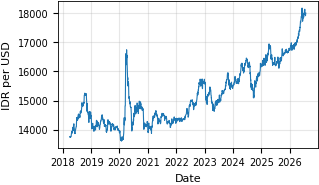

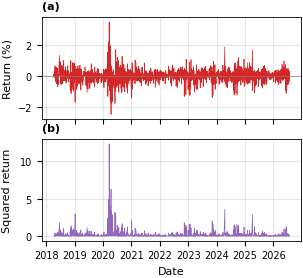

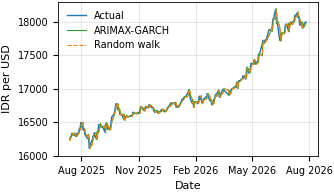

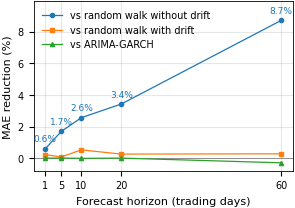

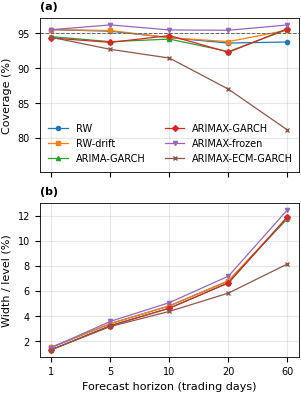

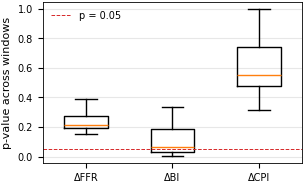

Saved figure1.png to figure6.png at 600 dpi, one-column width (8.5 cm).


In [125]:
import numpy as np, matplotlib.pyplot as plt, matplotlib.dates as mdates

COL_W = 3.35                                   # inches = 8.5 cm, one JAIC column
plt.rcParams.update({"font.size": 8, "axes.labelsize": 8, "xtick.labelsize": 7,
                     "ytick.labelsize": 7, "legend.fontsize": 7, "axes.linewidth": 0.6,
                     "lines.linewidth": 0.9, "savefig.dpi": 600, "savefig.bbox": "tight",
                     "savefig.pad_inches": 0.02})

def finish(fig, name):
    fig.savefig(name); plt.show(); plt.close(fig)

# Figure 1: exchange-rate level
fig, ax = plt.subplots(figsize=(COL_W, 1.9))
ax.plot(df.index, df["fx"], color="tab:blue", lw=0.8)
ax.set_xlabel("Date"); ax.set_ylabel("IDR per USD")
ax.xaxis.set_major_locator(mdates.YearLocator()); ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.grid(True, alpha=0.3); finish(fig, "figure1.png")

# Figure 2: log returns and squared returns
fig, (a1, a2) = plt.subplots(2, 1, figsize=(COL_W, 2.9), sharex=True)
a1.plot(data.index, y, color="tab:red", lw=0.5); a1.axhline(0, color="0.5", lw=0.5)
a1.set_ylabel("Return (%)")
a2.plot(data.index, y**2, color="tab:purple", lw=0.5); a2.set_ylabel("Squared return")
a2.set_xlabel("Date")
a2.xaxis.set_major_locator(mdates.YearLocator()); ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
for ax in (a1, a2): ax.grid(True, alpha=0.3)
a1.set_title("(a)", loc="left", fontsize=8, fontweight="bold"); a2.set_title("(b)", loc="left", fontsize=8, fontweight="bold")
fig.align_ylabels((a1, a2)); finish(fig, "figure2.png")

# Figure 3: last 250 one-day-ahead forecasts
f3_idx = np.arange(WINDOW, n)
f3_act = np.asarray(act[1], float)
f3_x = f3_act - np.asarray(err["arimax"][1], float)
f3_rw = f3_act - np.asarray(err["rw"][1], float)
k = min(250, len(f3_idx)); d3 = data.index[f3_idx[-k:]]
fig, ax = plt.subplots(figsize=(COL_W, 2.0))
ax.plot(d3, f3_act[-k:], color="tab:blue", lw=1.0, label="Actual")
ax.plot(d3, f3_x[-k:], color="tab:green", lw=0.8, label="ARIMAX-GARCH")
ax.plot(d3, f3_rw[-k:], color="tab:orange", lw=0.8, ls="--", label="Random walk")
ax.set_xlabel("Date"); ax.set_ylabel("IDR per USD")
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3)); ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax.legend(frameon=False, loc="upper left"); ax.grid(True, alpha=0.3); finish(fig, "figure3.png")

# Figure 4: MAE reduction of ARIMAX-GARCH by horizon
def mae(m, h): return np.mean(np.abs(err[m][h]))
red = {b: [100*(mae(b, h) - mae("arimax", h))/mae(b, h) for h in H] for b in ["rw", "rw_drift", "arima"]}
fig, ax = plt.subplots(figsize=(COL_W, 2.2))
ax.axhline(0, color="0.5", lw=0.6)
ax.plot(H, red["rw"], "-o", ms=3, color="tab:blue", label="vs random walk without drift")
ax.plot(H, red["rw_drift"], "-s", ms=3, color="tab:orange", label="vs random walk with drift")
ax.plot(H, red["arima"], "-^", ms=3, color="tab:green", label="vs ARIMA-GARCH")
for xv, vv in zip(H, red["rw"]):
    ax.annotate(f"{vv:.1f}%", (xv, vv), textcoords="offset points", xytext=(0, 5), ha="center", fontsize=6.5, color="tab:blue")
ax.set_ylim(min(min(v) for v in red.values()) - 0.5, max(red["rw"]) + 1.2)
ax.set_xticks(H); ax.set_xlabel("Forecast horizon (trading days)"); ax.set_ylabel("MAE reduction (%)")
ax.legend(frameon=False, loc="upper left"); ax.grid(True, alpha=0.3); finish(fig, "figure4.png")

# Figure 5: (a) coverage and (b) relative width of the 95% interval, stacked in one figure
cov_dict, relw_dict = {}, {}
for m in MODELS:
    cov_dict[m], relw_dict[m] = [], []
    for h in H:
        lo_val = np.array(band[m][h]["lo"])
        hi_val = np.array(band[m][h]["hi"])
        act_val = np.array(band[m][h]["act"])
        viol = ((act_val < lo_val) | (act_val > hi_val)).astype(int)
        cov_dict[m].append(100 * (1 - viol.mean()))
        relw_dict[m].append(100 * ((hi_val - lo_val) / act_val).mean())

xh = np.arange(len(H))
fig, (a1, a2) = plt.subplots(2, 1, figsize=(COL_W, 4.4), sharex=True)
for m in MODELS:
    a1.plot(xh, cov_dict[m], marker=mk[m], ms=3, lw=0.9, label=LAB[m])
    a2.plot(xh, relw_dict[m], marker=mk[m], ms=3, lw=0.9, label=LAB[m])
a1.axhline(95, ls="--", color="0.4", lw=0.7)
a1.set_ylabel("Coverage (%)"); a2.set_ylabel("Width / level (%)")
a2.set_xticks(xh); a2.set_xticklabels(H); a2.set_xlabel("Forecast horizon (trading days)")
a1.set_title("(a)", loc="left", fontsize=8, fontweight="bold")
a2.set_title("(b)", loc="left", fontsize=8, fontweight="bold")
a1.set_ylim(min(min(v) for v in cov_dict.values()) - 6, max(max(v) for v in cov_dict.values()) + 1)
a1.legend(frameon=False, loc="lower left", ncol=2)
for ax in (a1, a2): ax.grid(True, alpha=0.3)
fig.align_ylabels((a1, a2)); finish(fig, "figure5.png")

# Figure 6: distribution of macro-regressor p-values across rolling windows
fig, ax = plt.subplots(figsize=(COL_W, 2.1))
ax.boxplot([long_df.loc[long_df["param"] == c, "pval"].values for c in ["x0", "x1", "x2"]],
           showfliers=False, widths=0.5)
ax.set_xticks([1, 2, 3]); ax.set_xticklabels(["ΔFFR", "ΔBI", "ΔCPI"])
ax.axhline(0.05, ls="--", color="tab:red", lw=0.7, label="p = 0.05")
ax.set_ylabel("p-value across windows"); ax.legend(frameon=False, loc="upper left")
ax.grid(True, axis="y", alpha=0.3); finish(fig, "figure6.png")
print("Saved figure1.png to figure6.png at 600 dpi, one-column width (8.5 cm).")